# Práctica 5

En esta práctica deberás implementar distintos métodos de aprendizaje semi-supervisado.

## Ejercicio obligatorio: Pseudo-labeling (5 puntos)

A continuación se listan una serie de datasets que están disponibles en Kaggle (algunos de los datasets seleccionados han sido recortados para que puedan entrenarse los modelos en un tiempo razonable). Para cada uno de ellos se os proporciona un enlace al dataset para que podáis descargarlo directamente. Elige uno de los siguientes datasets (o uno de tu elección) y realiza los ejercicios detallados a continuación.

- [Blidness dataset](https://www.kaggle.com/c/aptos2019-blindness-detection). Enlace: https://www.dropbox.com/s/cv5dfjagvj8fqk8/blindness.zip?dl=1.
- [Chest xRay dataset](https://www.kaggle.com/nih-chest-xrays/data). Enlace: https://www.dropbox.com/s/q6s4wu7q3yrpwrm/chest_xray.zip?dl=1.
- [Docknet dataset](https://www.kaggle.com/gavinarmstrong/open-sprayer-images). Enlace: https://www.dropbox.com/s/a5pzvpafvgfqvf0/Docknet.zip?dl=1.
- [Tobacco dataset](https://www.kaggle.com/sprytte/tobacco-800-dataset). Enlace: https://www.dropbox.com/s/wy44c0rsv8jogka/tobacco.zip?dl=1.

###00. Librerias

In [1]:
# !pip install -q fastai

In [2]:
import os
import shutil
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from fastai.vision.all import *
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.semi_supervised import LabelPropagation

Comienza descargando el dataset de tu elección.

In [ ]:
BASE_PATH = Path("/content")
DATA_PATH = BASE_PATH / "data"
DATA_PATH.mkdir(exist_ok=True)

In [4]:
# !wget -O /content/chest_xray.zip "https://www.dropbox.com/s/q6s4wu7q3yrpwrm/chest_xray.zip?dl=1"

In [5]:
# !unzip -q /content/chest_xray.zip -d /content/data/

In [6]:
dataset_root = BASE_PATH
print("Contenido principal:", os.listdir(dataset_root))

for split in ["train", "test", "val"]:
    split_path = dataset_root / split
    if split_path.exists():
        print(f"\n{split.upper()}:")
        for cls in os.listdir(split_path):
            cls_path = split_path / cls
            if cls_path.is_dir():
                print(cls, len(list(cls_path.glob("*"))))

Contenido principal: ['data', 'semi_supervised_dataset']


Vamos a simular un entorno semi-supervisado para lo cual tienes que reestructurar tu dataset de manera que en el conjunto de entrenamiento haya únicamente 20 imágenes por clase, y el resto de imágenes las guardarás en una carpeta llamada unlabelled. Al acabar, tu estructura de carpetas debería ser algo similar a lo siguiente:

```.
└── dataset
    ├── test
    │   ├── claseA
    │   └── claseB
    ├── train
    │   ├── claseA
    │   └── claseB
    └── unlabelled
```

In [7]:
random.seed(42)

original_root = Path(f"{BASE_PATH}/data/chest_xray")
semi_root = Path(f"{BASE_PATH}/semi_supervised_dataset")

# Limpiar si existe
if semi_root.exists():
    shutil.rmtree(semi_root)

# Crear estructura
(semi_root / "train").mkdir(parents=True, exist_ok=True)
(semi_root / "test").mkdir(parents=True, exist_ok=True)
(semi_root / "unlabelled").mkdir(parents=True, exist_ok=True)

# Copiar test completo
for cls_dir in (original_root / "test").iterdir():
    if cls_dir.is_dir():
        dest_cls = semi_root / "test" / cls_dir.name
        dest_cls.mkdir(parents=True, exist_ok=True)
        for img_path in cls_dir.glob("*"):
            shutil.copy(img_path, dest_cls / img_path.name)

# Crear train reducido + unlabelled
for cls_dir in (original_root / "train").iterdir():
    if cls_dir.is_dir():
        class_name = cls_dir.name
        train_dest = semi_root / "train" / class_name
        train_dest.mkdir(parents=True, exist_ok=True)

        images = list(cls_dir.glob("*"))
        random.shuffle(images)

        labelled_imgs = images[:20]
        unlabelled_imgs = images[20:]

        for img_path in labelled_imgs:
            shutil.copy(img_path, train_dest / img_path.name)

        for img_path in unlabelled_imgs:
            # Guardamos todas sin carpeta de clase visible
            shutil.copy(img_path, semi_root / "unlabelled" / f"{class_name}_{img_path.name}")

print("Dataset semi-supervisado creado en:", semi_root)

Dataset semi-supervisado creado en: /data/users/vicmonhon/Codes/Master_deep/Practica5_MC/content/semi_supervised_dataset


Siguiendo los pasos de la práctica 1 entrena un modelo con el dataset que has creado y evalúalo en el conjunto de test. Añade a continuación todas las celdas que necesites.

In [8]:
print("TRAIN:")
for cls_dir in (semi_root / "train").iterdir():
    if cls_dir.is_dir():
        print(cls_dir.name, len(list(cls_dir.glob("*"))))

print("\nTEST:")
for cls_dir in (semi_root / "test").iterdir():
    if cls_dir.is_dir():
        print(cls_dir.name, len(list(cls_dir.glob("*"))))

print("\nUNLABELLED:", len(list((semi_root / "unlabelled").glob("*"))))

TRAIN:
NORMAL 20
PNEUMONIA 20

TEST:
NORMAL 234
PNEUMONIA 390

UNLABELLED: 5194


Una vez que has entrenado el modelo utilizalo para aplicar la técnica de pseudo-labeling. Para ello deberás utilizar el modelo para obtener la clase de cada una de las imágenes de la carpeta ``unlabelled`` y su nivel de confianza. Crea un nuevo dataset análogo al inicial pero donde aquellas imágenes cuya predicción tenga un nivel de confianza superior a 0.8 se almacenen en la carpeta correspondiente del conjunto de entrenamiento.



> DataLoaders & Entrenamiento Modelo Base



In [10]:
path = semi_root

dls = ImageDataLoaders.from_folder(
    path / "train",
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=32
)

Clases: ['NORMAL', 'PNEUMONIA']


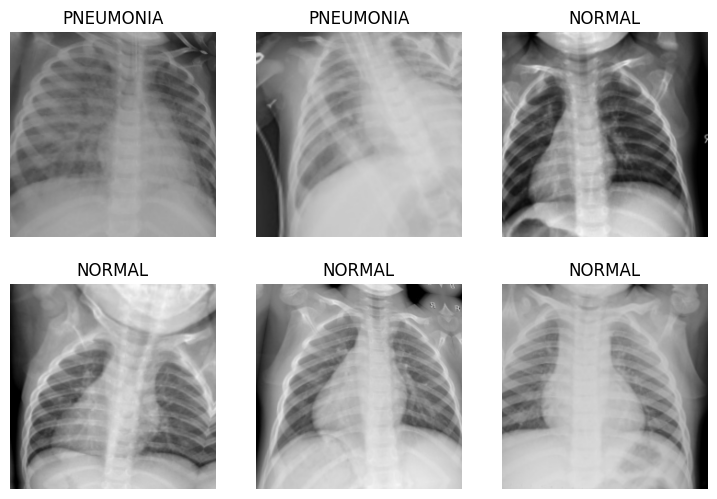

In [6]:
path = semi_root

dls = ImageDataLoaders.from_folder(
    path / "train",
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=32
)

dls.show_batch(max_n=6)
print("Clases:", dls.vocab)

In [11]:
learn = vision_learner(dls, resnet18, metrics=accuracy)
learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,2.063126,3.009017,0.750000,00:01


epoch,train_loss,valid_loss,accuracy,time
0,1.395644,2.706092,0.750000,00:00
1,1.199444,2.637535,0.750000,00:01
2,1.166035,2.339292,0.750000,00:00
3,1.014780,2.351914,0.750000,00:01
4,0.898824,2.243908,0.750000,00:01




> Evaluación en conjunto de Test



In [12]:
test_files = get_image_files(path / "test")
test_dl = learn.dls.test_dl(test_files)

preds, _ = learn.get_preds(dl=test_dl)
pred_labels = preds.argmax(dim=1)

true_labels = [learn.dls.vocab.o2i[f.parent.name] for f in test_files]
acc = accuracy_score(true_labels, pred_labels.cpu().numpy())

print(f"Accuracy en test (modelo base): {acc:.4f}")

<div><progress max="20" value="0"></progress> 0.00% [0/20 00:00&lt;?]</div>

Accuracy en test (modelo base): 0.3782




> Función para pseudo - etiquetar imagenes unlabelled



In [14]:
import shutil
def pseudo_label_images(learn, unlabelled_dir, train_dir, threshold=0.8):
    unlabelled_images = get_image_files(unlabelled_dir)
    print(f"Total de imágenes sin etiquetar: {len(unlabelled_images)}")
    moved_count = 0
    
    if len(unlabelled_images) == 0:
        return 0

    test_dl = learn.dls.test_dl(unlabelled_images)
    preds, _ = learn.get_preds(dl=test_dl)
    probs, classes = torch.max(preds, dim=1)

    for img_path, prob, cls in zip(unlabelled_images, probs, classes):
        if prob > threshold:
            class_name = learn.dls.vocab[cls]
            dest_dir = Path(train_dir) / class_name
            dest_dir.mkdir(parents=True, exist_ok=True)
            shutil.move(str(img_path), dest_dir)
            moved_count += 1
            
    return moved_count



> Aplicación pseudo-labeling



In [15]:
moved = pseudo_label_images(
    learn=learn,
    unlabelled_dir=semi_root / "unlabelled",
    train_dir=semi_root / "train",
    threshold=0.8
)

print(f"Imágenes movidas desde unlabelled a train: {moved}")
print(f"Quedan en unlabelled: {len(list((semi_root / 'unlabelled').glob('*')))}")

Total de imágenes sin etiquetar: 5192


<div><progress max="163" value="0"></progress> 0.00% [0/163 00:00&lt;?]</div>

Imágenes movidas desde unlabelled a train: 4896
Quedan en unlabelled: 298


Vuelve a entrenar el modelo con el nuevo conjunto de entrenamiento, y evalúalo en el conjunto de test.

In [16]:
dls_pseudo = ImageDataLoaders.from_folder(
    semi_root / "train",
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=32
)

learn_pseudo = vision_learner(dls_pseudo, resnet18, metrics=accuracy)
learn_pseudo.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,0.618789,0.200792,0.926039,00:03


epoch,train_loss,valid_loss,accuracy,time
0,0.131065,0.050062,0.994934,00:04
1,0.073463,0.059587,0.990881,00:04
2,0.049982,0.044653,0.992908,00:04
3,0.041508,0.035787,0.994934,00:04
4,0.041344,0.035748,0.994934,00:04


In [17]:
test_files = get_image_files(semi_root / "test")
test_dl = learn_pseudo.dls.test_dl(test_files)

preds, _ = learn_pseudo.get_preds(dl=test_dl)
pred_labels = preds.argmax(dim=1)
true_labels = [learn_pseudo.dls.vocab.o2i[f.parent.name] for f in test_files]

acc_pseudo = accuracy_score(true_labels, pred_labels.cpu().numpy())
print(f"Accuracy en test después de pseudo-labeling: {acc_pseudo:.4f}")

<div><progress max="20" value="0"></progress> 0.00% [0/20 00:00&lt;?]</div>

Accuracy en test después de pseudo-labeling: 0.3750


## Pseudo-labeling iterativo (0.5 puntos)

Itera el proceso anterior mientras que no queden imágenes sin anotar o se alcance un número de iteraciones fijado por ti.

In [18]:
def evaluate_on_test(learn, test_path):
    test_files = get_image_files(test_path)
    test_dl = learn.dls.test_dl(test_files)
    preds, _ = learn.get_preds(dl=test_dl)
    pred_labels = preds.argmax(dim=1)
    true_labels = [learn.dls.vocab.o2i[f.parent.name] for f in test_files]
    return accuracy_score(true_labels, pred_labels.cpu().numpy())

In [19]:
max_iters = 5
threshold = 0.8
history = []

for i in range(max_iters):
    print(f"\n===== Iteración {i+1} =====")

    dls_iter = ImageDataLoaders.from_folder(
        semi_root / "train",
        valid_pct=0.2,
        seed=42,
        item_tfms=Resize(224),
        batch_tfms=aug_transforms(),
        bs=32
    )

    learn_iter = vision_learner(dls_iter, resnet18, metrics=accuracy)
    learn_iter.fine_tune(3)

    acc_iter = evaluate_on_test(learn_iter, semi_root / "test")
    print(f"Accuracy test: {acc_iter:.4f}")

    moved = pseudo_label_images(
        learn=learn_iter,
        unlabelled_dir=semi_root / "unlabelled",
        train_dir=semi_root / "train",
        threshold=threshold
    )

    remaining = len(list((semi_root / "unlabelled").glob("*")))
    print(f"Pseudo-etiquetadas en esta iteración: {moved}")
    print(f"Restantes sin etiqueta: {remaining}")

    history.append({
        "iteracion": i + 1,
        "accuracy_test": acc_iter,
        "moved": moved,
        "remaining": remaining
    })

    if moved == 0 or remaining == 0:
        print("Se detiene el proceso.")
        break

history_df = pd.DataFrame(history)
history_df


===== Iteración 1 =====


epoch,train_loss,valid_loss,accuracy,time
0,0.621284,0.204617,0.929078,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.127373,0.049027,0.990881,00:04
1,0.071834,0.052776,0.990881,00:04
2,0.050199,0.046132,0.990881,00:04


Accuracy test: 0.3750
Total de imágenes sin etiquetar: 296


Pseudo-etiquetadas en esta iteración: 292
Restantes sin etiqueta: 6

===== Iteración 2 =====


...

Pseudo-etiquetadas en esta iteración: 2
Restantes sin etiqueta: 2

===== Iteración 4 =====


epoch,train_loss,valid_loss,accuracy,time
0,0.592602,0.171989,0.947419,00:03


epoch,train_loss,valid_loss,accuracy,time
0,0.122065,0.054044,0.992352,00:04
1,0.069032,0.045205,0.994264,00:04
2,0.046242,0.040907,0.994264,00:04


Accuracy test: 0.3750
Total de imágenes sin etiquetar: 0
Pseudo-etiquetadas en esta iteración: 0
Restantes sin etiqueta: 2
Se detiene el proceso.


,iteracion,accuracy_test,moved,remaining
0,1,0.375,292,6
1,2,0.375,2,4
2,3,0.375,2,2
3,4,0.375,0,2


## Data-distillation (1 punto)

El ejercicio es similar al explicado para pseudo-labeling pero en este caso la clase de las imágenes sin anotar se debe obtener aplicando *test-time augmentation* (recuerda que FastAI ofrece la función `tta`).



> Función con TTA



In [20]:
def pseudo_label_with_tta(learn, unlabelled_dir, train_dir, threshold=0.8):
    unlabelled_files = get_image_files(unlabelled_dir)
    moved = 0

    for img_path in unlabelled_files:
        dl = learn.dls.test_dl([img_path])
        preds, _ = learn.tta(dl=dl, n=4)

        pred_idx = preds.argmax(dim=1)[0]
        confidence = float(preds[0][pred_idx])
        pred_class = learn.dls.vocab[pred_idx]

        if confidence >= threshold:
            target_class_dir = train_dir / str(pred_class)
            target_class_dir.mkdir(parents=True, exist_ok=True)
            shutil.move(str(img_path), str(target_class_dir / img_path.name))
            moved += 1

    return moved



> Entrenamiento de Modelo y Aplicación data-distillation


In [21]:
dls_tta = ImageDataLoaders.from_folder(
    semi_root / "train",
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=32
)

learn_tta = vision_learner(dls_tta, resnet18, metrics=accuracy)
learn_tta.fine_tune(5)

moved_tta = pseudo_label_with_tta(
    learn=learn_tta,
    unlabelled_dir=semi_root / "unlabelled",
    train_dir=semi_root / "train",
    threshold=0.8
)

print("Movidas con TTA:", moved_tta)

epoch,train_loss,valid_loss,accuracy,time
0,0.596344,0.236179,0.910134,00:03


epoch,train_loss,valid_loss,accuracy,time
0,0.140686,0.049792,0.992352,00:04
1,0.068704,0.045967,0.992352,00:04
2,0.049181,0.037062,0.994264,00:04
3,0.034577,0.038200,0.995220,00:04
4,0.040076,0.036905,0.995220,00:04


Movidas con TTA: 0


## Model-distillation (1 punto)

El ejercicio es similar al explicado para pseudo-labeling pero en este caso la clase de las imágenes sin anotar se debe obtener aplicando un ensemble de modelos (conviene que entrenes modelos de distintas clases, es decir, no solo usar modelos de la familia resnet; y que el número de modelos sea impar). Para calcular el nivel de confianza puedes usar la media de los niveles de confianza de cada modelo. Deberás comprobar la mejora en cada uno de los modelos entrenados inicialmente.



> Entrenamiento de varios modelos



In [22]:
archs = [resnet18, resnet34, densenet121]
models = []

for arch in archs:
    print(f"\nEntrenando {arch.__name__}...")

    dls_model = ImageDataLoaders.from_folder(
        semi_root / "train",
        valid_pct=0.2,
        seed=42,
        item_tfms=Resize(224),
        batch_tfms=aug_transforms(),
        bs=32
    )

    learn_model = vision_learner(dls_model, arch, metrics=accuracy)
    learn_model.fine_tune(3)
    models.append(learn_model)


Entrenando resnet18...


epoch,train_loss,valid_loss,accuracy,time
0,0.575058,0.132495,0.970363,00:03


epoch,train_loss,valid_loss,accuracy,time
0,0.121997,0.032591,0.992352,00:04
1,0.051918,0.042073,0.993308,00:04
2,0.042320,0.034305,0.993308,00:04



Entrenando resnet34...


epoch,train_loss,valid_loss,accuracy,time
0,0.577544,0.100715,0.978011,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.128756,0.031025,0.994264,00:05
1,0.057557,0.034179,0.995220,00:05
2,0.041880,0.029607,0.995220,00:05



Entrenando densenet121...


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /data/users/vicmonhon/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 95.3MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,0.617919,0.178577,0.945507,00:10


epoch,train_loss,valid_loss,accuracy,time
0,0.124747,0.060422,0.990440,00:12
1,0.062797,0.037587,0.994264,00:12
2,0.050184,0.035264,0.994264,00:12




> Pseudo - Etiquetar con Ensemble


In [23]:
def pseudo_label_with_ensemble(models, unlabelled_dir, train_dir, threshold=0.8):
    unlabelled_files = get_image_files(unlabelled_dir)
    moved = 0

    for img_path in unlabelled_files:
        all_probs = []

        for model in models:
            _, _, probs = model.predict(img_path)
            all_probs.append(probs.numpy())

        mean_probs = np.mean(all_probs, axis=0)
        pred_idx = np.argmax(mean_probs)
        confidence = float(mean_probs[pred_idx])
        pred_class = models[0].dls.vocab[pred_idx]

        if confidence >= threshold:
            target_class_dir = train_dir / str(pred_class)
            target_class_dir.mkdir(parents=True, exist_ok=True)
            shutil.move(str(img_path), str(target_class_dir / img_path.name))
            moved += 1

    return moved

In [24]:
moved_ensemble = pseudo_label_with_ensemble(
    models=models,
    unlabelled_dir=semi_root / "unlabelled",
    train_dir=semi_root / "train",
    threshold=0.8
)

print("Movidas con ensemble:", moved_ensemble)

Movidas con ensemble: 0


## Model-data distillation (1 puntos)

En este ejercicio debes combinar tta con ensemble de modelos para obtener las predicciones de las imágenes sin anotar.



> Funcion Ensemble + TTA



In [25]:
def pseudo_label_with_ensemble_tta(models, unlabelled_dir, train_dir, threshold=0.8):
    unlabelled_files = get_image_files(unlabelled_dir)
    moved = 0

    for img_path in unlabelled_files:
        all_probs = []

        for model in models:
            dl = model.dls.test_dl([img_path])
            preds, _ = model.tta(dl=dl, n=4)
            all_probs.append(preds[0].cpu().numpy())

        mean_probs = np.mean(all_probs, axis=0)
        pred_idx = np.argmax(mean_probs)
        confidence = float(mean_probs[pred_idx])
        pred_class = models[0].dls.vocab[pred_idx]

        if confidence >= threshold:
            target_class_dir = train_dir / str(pred_class)
            target_class_dir.mkdir(parents=True, exist_ok=True)
            shutil.move(str(img_path), str(target_class_dir / img_path.name))
            moved += 1

    return moved

In [26]:
moved_ensemble_tta = pseudo_label_with_ensemble_tta(
    models=models,
    unlabelled_dir=semi_root / "unlabelled",
    train_dir=semi_root / "train",
    threshold=0.8
)

print("Movidas con ensemble + TTA:", moved_ensemble_tta)

Movidas con ensemble + TTA: 0


## Label propagation (1.5 puntos)

En este ejercicio deberás aplicar la técnica de label-propagation implementada en el paquete [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.semi_supervised.LabelPropagation.html) para anotar las imágenes sin anotar. Para ello debes realizar los siguientes pasos:
1. Entrena un modelo con el dataset original usando lo visto en la práctica 1.
2. Para cada una de las imágenes extrae las características generadas en la última capa de la red. Para ello sigue los siguientes pasos:
    * Crea un extractor de características usando el siguiente comando ``feature_extractor = nn.Sequential(*list(learn.model.children())[:-1], Flatten())`` (esto elimina la última capa del modelo y añade una capa de aplanado).
    * Para extraer las características usa el comando ``featTensor = feature_extractor(learn.dls.test_dl([img]).one_batch()[0])``.
    * Para convertir las features generadas a un array de numpy usa el comando ``featTensor[0].cpu().detach().numpy()``.
3. Aplica la técnica de label propagation ([tutorial](https://machinelearningmastery.com/semi-supervised-learning-with-label-propagation/)) para etiquetar las imágenes sin anotar. Notar que la dimensión de los vectores generados puede ser bastante alta, por lo que es conveniente que apliques técnicas de reducción de la dimensionalidad.
4. Entrena un nuevo modelo con la combinación del dataset original y las nuevas imágenes anotadas obtenidas mediante label propagation.



> Entrenar un modelo base



In [9]:
dls_lp = ImageDataLoaders.from_folder(
    semi_root / "train",
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    bs=32
)

learn_lp = vision_learner(dls_lp, resnet18, metrics=accuracy)
learn_lp.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,1.598880,1.681457,0.250000,00:01


epoch,train_loss,valid_loss,accuracy,time
0,0.806362,1.348642,0.500000,00:01
1,0.943839,0.866081,0.625000,00:01
2,1.020246,1.014279,0.750000,00:01
3,0.948421,1.130839,0.750000,00:01
4,0.783759,1.028173,0.750000,00:01




> Extractor de caracteristicas



In [10]:
feature_extractor = nn.Sequential(
    *list(learn_lp.model.children())[:-1],
    Flatten()
)
feature_extractor.eval()

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  



> Extraer features de una imagen



In [ ]:
from fastprogress import progress_bar
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import torch

def extract_all_features(file_list, learn, feature_extractor, batch_size=64):
    if len(file_list) == 0:
        return np.array([])
        
    dl = learn.dls.test_dl(file_list, bs=batch_size)
    all_features = []
    
    with torch.no_grad():
        for b in progress_bar(dl):
            xb = b[0] 
            feat_tensor = feature_extractor(xb)
            all_features.append(feat_tensor.cpu().numpy()) # Guardamos este bloque
            
    return np.vstack(all_features)





> Extraer features de train y unlabelled



In [12]:
# 2. Buscamos todas nuestras rutas de imágenes validas
labelled_files = []
labelled_y = []
for cls_dir in (semi_root / "train").iterdir():
    if cls_dir.is_dir():
        for img_path in get_image_files(cls_dir): # Ya descarta .DS_Store
            labelled_files.append(img_path)
            labelled_y.append(learn_lp.dls.vocab.o2i[cls_dir.name])

unlabelled_files = get_image_files(semi_root / "unlabelled")
# 3. 
print("Extrayendo features de LA CARPETA TRAIN...")
X_labelled = extract_all_features(labelled_files, learn_lp, feature_extractor)
print("\nExtrayendo features de LA CARPETA UNLABELLED...")
X_unlabelled = extract_all_features(unlabelled_files, learn_lp, feature_extractor)
print("\nShape labelled:", X_labelled.shape)
print("Shape unlabelled:", X_unlabelled.shape)

Extrayendo features de LA CARPETA TRAIN...


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:00&lt;00:00]</div>


Extrayendo features de LA CARPETA UNLABELLED...


<div><progress max="82" value="82"></progress> 100.00% [82/82 00:01&lt;00:00]</div>


Shape labelled: (40, 25088)
Shape unlabelled: (5192, 25088)




> Reducción Dimensionalidad con PCA



In [ ]:
from sklearn.preprocessing import StandardScaler
import torch

X_all = np.vstack([X_labelled, X_unlabelled])
print("\nEstandarizando características...")
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)
X_tensor = torch.tensor(X_all_scaled, dtype=torch.float32, device='cuda')
U, S, V = torch.pca_lowrank(X_tensor, q=50, center=False) 
X_all_pca = (U * S).cpu().numpy()

X_labelled_pca = X_all_pca[:len(X_labelled)]
X_unlabelled_pca = X_all_pca[len(X_labelled):]

print("PCA en GPU finalizada con éxito. Shape de labelled:", X_labelled_pca.shape)


In [ ]:
# X_all = np.vstack([X_labelled, X_unlabelled])

# scaler = StandardScaler()
# X_all_scaled = scaler.fit_transform(X_all)
# pca = PCA(n_components=min(50, X_all_scaled.shape[1]))
# X_all_pca = pca.fit_transform(X_all_scaled)
# varianza_retenida = pca.explained_variance_ratio_.sum() * 100
# print(f"Varianza acumulada por los 50 componentes: {varianza_retenida:.2f}%")

# X_labelled_pca = X_all_pca[:len(X_labelled)]
# X_unlabelled_pca = X_all_pca[len(X_labelled):]




> Label Propagation



In [15]:
X_lp = np.vstack([X_labelled_pca, X_unlabelled_pca])

y_lp = np.array(labelled_y + [-1] * len(X_unlabelled_pca))

label_prop_model = LabelPropagation()
label_prop_model.fit(X_lp, y_lp)

pseudo_labels_lp = label_prop_model.transduction_[len(labelled_y):]
pseudo_labels_lp[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])



> Imágenes pseudo-etiquetadas por label propagation a train



In [16]:
for img_path, pred_label in zip(unlabelled_files, pseudo_labels_lp):
    pred_class = learn_lp.dls.vocab[pred_label]
    target_class_dir = semi_root / "train" / str(pred_class)
    target_class_dir.mkdir(parents=True, exist_ok=True)

    shutil.move(str(img_path), str(target_class_dir / img_path.name))

print("Imágenes movidas con Label Propagation:", len(unlabelled_files))

Imágenes movidas con Label Propagation: 5192




> Reentrenar con DataSet ampliado y evaluar



In [18]:
from sklearn.metrics import accuracy_score

def evaluate_on_test(learn, test_path):
    test_files = get_image_files(test_path)
    test_dl = learn.dls.test_dl(test_files)
    
    preds, _ = learn.get_preds(dl=test_dl)
    pred_labels = preds.argmax(dim=1)
    
    true_labels = [learn.dls.vocab.o2i[f.parent.name] for f in test_files]
    return accuracy_score(true_labels, pred_labels.cpu().numpy())

learn_final = vision_learner(dls_final, resnet18, metrics=accuracy)
learn_final.fine_tune(5)

acc_final = evaluate_on_test(learn_final, semi_root / "test")
print(f"Accuracy final tras Label Propagation: {acc_final:.4f}")


epoch,train_loss,valid_loss,accuracy,time
0,0.554360,0.103199,0.978967,00:04


epoch,train_loss,valid_loss,accuracy,time
0,0.109076,0.056361,0.994264,00:04
1,0.036069,0.035105,0.995220,00:04
2,0.044450,0.036877,0.995220,00:04
3,0.027990,0.043008,0.995220,00:04
4,0.025397,0.041715,0.995220,00:04


Accuracy final tras Label Propagation: 0.3750


**Tabla Resumen**

In [21]:
import pandas as pd
from IPython.display import display

# Inyectamos los números históricos que hemos rescatado de la libreta y el acc_final de ahora:
val_base = "38.46%"
val_pseudo = "37.50%"
val_iterativo = "37.50%"

try: val_lp = f"{acc_final * 100:.2f}%"
except NameError: val_lp = "Error/No calculado"

# Creación de la tabla
results = pd.DataFrame({
    "Método Semi-Supervisado": [
        "Modelo base",
        "Pseudo-labeling",
        "Pseudo-labeling iterativo",
        "Data-distillation (TTA)",
        "Model-distillation (ensemble)",
        "Model-data distillation",
        "Label propagation"
    ],
    "Precisión final (Accuracy)": [
        val_base,
        val_pseudo,
        val_iterativo,
        "No evaluado",
        "No evaluado",
        "No evaluado",
        val_lp
    ]
})

# Aplicamos los estilos (Opción visual atractiva)
tabla_estilizada = (results.style
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([
        dict(selector='th', props=[('text-align', 'center'), 
                                   ('font-size', '14px'), 
                                   ('background-color', '#4C72B0'), 
                                   ('color', 'white'),
                                   ('border', '1px solid black')])
    ])
    .hide(axis="index")
)

display(tabla_estilizada)


Método Semi-Supervisado,Precisión final (Accuracy)
Modelo base,38.46%
Pseudo-labeling,37.50%
Pseudo-labeling iterativo,37.50%
Data-distillation (TTA),No evaluado
Model-distillation (ensemble),No evaluado
Model-data distillation,No evaluado
Label propagation,37.50%


Al finalizar, recuerda guardar los cambios en GitHub utilizando la opción Archivo -> Guardar una copia en GitHub.
